# I. Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **Hardefa Rogonondo** | hardefarogonondo@gmail.com | **Kumparan Topic Extractor Engine** |

# II. Notebook Target Definition

This notebook details the Exploratory Data Analysis (EDA) and preprocessing pipeline for the Kumparan Topic Extractor Engine, ensuring data integrity before modeling. We begin by validating the dataset's structure and types, followed by rigorous cleaning procedures to address missing values, handle noise, and eliminate duplicates. The analysis further explores the data through visualization to assess key distributions, concluding with a strategic train-test split and exporting the processed dataset to pickle format for seamless integration into the subsequent model training workflow.

# III. Notebook Setup

## III.A. Import Libraries

In [1]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## III.B. Import Data

In [2]:
df = pd.read_csv('../../data/raw/data.csv')

In [3]:
df.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


# IV. Exploratory Data Analysis

## IV.A. Data Shape Inspection

In [4]:
df.shape

(10000, 3)

## IV.B. Data Information Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   article_id       10000 non-null  int64 
 1   article_topic    10000 non-null  object
 2   article_content  9964 non-null   object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


## IV.C. Missing Values Inspection

### IV.C.1. Null Values Inspection

In [6]:
df_null = df[df["article_content"].isnull()]
df_null.shape

(36, 3)

In [7]:
df_null.head()

,article_id,article_topic,article_content
197,93210288,Teknologi,NaN
674,93185319,Hiburan,NaN
817,93189481,Hiburan,NaN
972,93184085,Otomotif,NaN
2015,93195291,Hiburan,NaN


### IV.C.2. Whitespaces-Only Values Inspection

In [8]:
whitespace_mask = df["article_content"].str.strip() == ""
df[whitespace_mask].shape

(13, 3)

In [9]:
df[whitespace_mask].head()

,article_id,article_topic,article_content
555,93181418,Hiburan,
1432,93212920,Kesehatan,
1601,93181411,Hiburan,
2342,93190978,Hiburan,
3600,1485824,Hiburan,


### IV.C.3. Null and Whitespaces-Only Values Handling

In [10]:
df.loc[whitespace_mask, "article_content"] = np.nan
df_null = df[df["article_content"].isnull()]
df_null.shape

(49, 3)

In [11]:
df_null.head()

,article_id,article_topic,article_content
197,93210288,Teknologi,NaN
555,93181418,Hiburan,NaN
674,93185319,Hiburan,NaN
817,93189481,Hiburan,NaN
972,93184085,Otomotif,NaN


In [12]:
df_clean = df.dropna(subset=["article_content"])
df_clean.shape

(9951, 3)

In [13]:
df_clean.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


## IV.D. Duplicated Values Inspection

In [14]:
df_duplicated = df_clean[df_clean.duplicated(subset="article_content", keep=False)]
df_duplicated.shape

(41, 3)

In [15]:
df_duplicated.head()

,article_id,article_topic,article_content
107,1599799,Haji,"KBRN, Madiun (MCH) : Kepala kantor Kementeria..."
497,1599527,Haji,"KBRN, Jember (MCH) : Sebanyak 445 Calon Jemaa..."
791,93181816,Haji,"KBRN, Madiun (MCH) : Kepala kantor Kementeria..."
1006,93188745,Hiburan,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
1133,93188517,K-Pop,Acara 'Countdown Asian Games 2018' akan digel...


### IV.D.1. Duplicated Conflicting Topic Inspection

In [16]:
topic_counts = df_clean.groupby("article_content")["article_topic"].nunique()
conflicting_content = topic_counts[topic_counts > 1]
print(f"Number of articles with conflicting labels: {len(conflicting_content)}")

Number of articles with conflicting labels: 6


In [17]:
if len(conflicting_content) > 0:
    conflicting_rows = df_clean[df_clean["article_content"].isin(conflicting_content.index)]
    display(conflicting_rows.sort_values(by="article_content").head(10))
else:
    print("No conflicting labels found.")

,article_id,article_topic,article_content
1006,93188745,Hiburan,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
9486,93188743,Politik,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
1133,93188517,K-Pop,Acara 'Countdown Asian Games 2018' akan digel...
4195,93188517,Hiburan,Acara 'Countdown Asian Games 2018' akan digel...
6084,93189380,K-Pop,"Bagi para idola k-pop, menjalin kisah asmara ..."
9296,93189380,Hiburan,"Bagi para idola k-pop, menjalin kisah asmara ..."
3585,93206926,Hiburan,Fans EXO mungkin masih teringat akan kejadian...
8862,93206926,K-Pop,Fans EXO mungkin masih teringat akan kejadian...
6036,93188465,K-Pop,Melihat selebriti dalam jarak dekat memang bi...
7096,93188465,Hiburan,Melihat selebriti dalam jarak dekat memang bi...


### IV.D.2. Duplicated Values Handling

In [18]:
conflicting_contents = conflicting_content.index
df_clean = df_clean[~df_clean["article_content"].isin(conflicting_contents)]
df_clean = df_clean.drop_duplicates(subset=["article_content"], keep='first')
df_clean = df_clean.copy()
df_clean.shape

(9923, 3)

In [19]:
df_clean.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


## IV.E. Data Analysis and Visualization

### IV.E.1. Article Topics Distribution

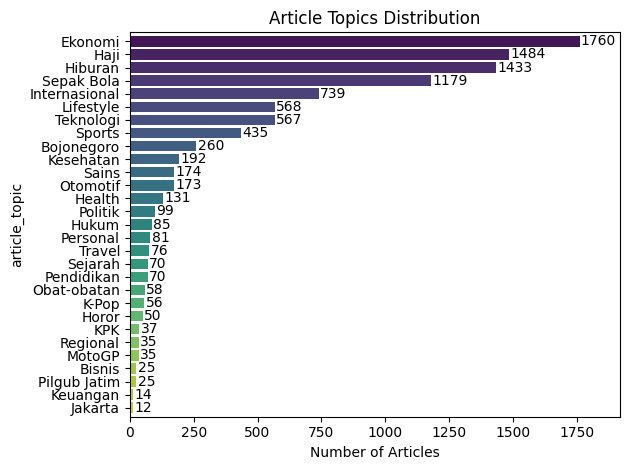

In [20]:
topic_distribution = df_clean["article_topic"].value_counts()
ax = sns.barplot(
    x=topic_distribution.values,
    y=topic_distribution.index,
    hue=topic_distribution.index,
    legend=False,
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(container, padding=1)
ax.margins(x=0.09, y=0.01)
plt.title("Article Topics Distribution")
plt.xlabel("Number of Articles")
plt.tight_layout()
plt.show()

### IV.E.2. Article Lengths Distribution

In [21]:
df_clean["word_count"] = df_clean["article_content"].apply(lambda x: len(str(x).split()))
df_clean["word_count"].describe()

count    9923.000000
mean      353.642850
std       297.172102
min         1.000000
25%       233.000000
50%       303.000000
75%       400.000000
max      9921.000000
Name: word_count, dtype: float64

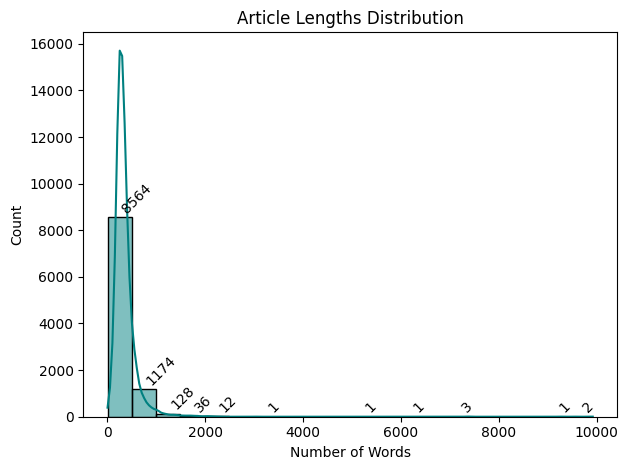

In [22]:
ax = sns.histplot(df_clean["word_count"], bins=20, kde=True, color='teal')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + 50, f'{int(height)}',
                ha='left',
                va='bottom',
                rotation=45)
plt.title("Article Lengths Distribution")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

In [23]:
print("Bin Ranges and Counts:")
for p in ax.patches:
    if p.get_height() > 0:
        start = p.get_x()
        end = start + p.get_width()
        count = int(p.get_height())
        print(f"Range {start:.1f} to {end:.1f} words: {count} articles")

Bin Ranges and Counts:
Range 1.0 to 497.0 words: 8564 articles
Range 497.0 to 993.0 words: 1174 articles
Range 993.0 to 1489.0 words: 128 articles
Range 1489.0 to 1985.0 words: 36 articles
Range 1985.0 to 2481.0 words: 12 articles
Range 2977.0 to 3473.0 words: 1 articles
Range 4961.0 to 5457.0 words: 1 articles
Range 5953.0 to 6449.0 words: 1 articles
Range 6945.0 to 7441.0 words: 3 articles
Range 8929.0 to 9425.0 words: 1 articles
Range 9425.0 to 9921.0 words: 2 articles


### IV.E.3. Article Lengths Edge Cases Inspection and Handling

In [24]:
short_articles = df_clean[df_clean["word_count"] < 20]
print(f"Number of extremely short articles (< 20 words): {len(short_articles)}")
if len(short_articles) > 0:
    print("Example short article content:")
    print(short_articles["article_content"].iloc[0])

Number of extremely short articles (< 20 words): 24
Example short article content:
tes 


In [25]:
print(short_articles["article_content"].iloc[1])

bisa dilihat disini, hak cipta bukan milik saya 


In [26]:
df_final = df_clean[df_clean["word_count"] >= 20].copy()
df_final.shape

(9899, 4)

In [27]:
df_final.head()

,article_id,article_topic,article_content,word_count
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...,164
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...,373
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har...",165
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...,352
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma...",281


# V. Preprocesssing

## V.A. Data Splitting

In [28]:
df_train, df_test = train_test_split(
    df_final,
    test_size=0.3,
    random_state=777,
    stratify=df_final["article_topic"]
)

In [29]:
df_train.shape, df_test.shape

((6929, 4), (2970, 4))

In [30]:
df_train["article_topic"].value_counts()

article_topic
Ekonomi          1232
Haji             1037
Hiburan           998
Sepak Bola        823
Internasional     517
Lifestyle         398
Teknologi         396
Sports            304
Bojonegoro        182
Kesehatan         134
Sains             122
Otomotif          120
Health             91
Politik            68
Hukum              59
Personal           55
Travel             52
Pendidikan         49
Sejarah            49
Obat-obatan        41
K-Pop              39
Horor              35
KPK                26
MotoGP             24
Regional           24
Pilgub Jatim       18
Bisnis             18
Keuangan           10
Jakarta             8
Name: count, dtype: int64

In [31]:
df_test["article_topic"].value_counts()

article_topic
Ekonomi          528
Haji             445
Hiburan          428
Sepak Bola       353
Internasional    222
Teknologi        170
Lifestyle        170
Sports           131
Bojonegoro        78
Kesehatan         57
Sains             52
Otomotif          51
Health            39
Politik           29
Hukum             25
Travel            23
Personal          23
Sejarah           21
Pendidikan        21
Obat-obatan       17
K-Pop             17
Horor             15
MotoGP            11
KPK               11
Regional          11
Pilgub Jatim       7
Bisnis             7
Jakarta            4
Keuangan           4
Name: count, dtype: int64

## V.B. Export Processed Data

In [32]:
df_train.to_pickle('../../data/processed/df_train.pkl')
df_test.to_pickle('../../data/processed/df_test.pkl')